<a href="https://colab.research.google.com/github/AnshulKumar79/MediPredict---AI-powered-clinical-assistant/blob/main/train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
import os
print("Upload your kaggle.json file below:")
uploaded = files.upload()


!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000
!unzip -q skin-cancer-mnist-ham10000.zip -d dataset/
print("Dataset successfully downloaded and unzipped into Colab!")

Upload your kaggle.json file below:


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
skin-cancer-mnist-ham10000.zip: Skipping, found more recently modified local copy (use --force to force download)
replace dataset/HAM10000_images_part_1/ISIC_0024306.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: Dataset successfully downloaded and unzipped into Colab!


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from PIL import Image
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
base_dir = 'dataset'
img_dir_1 = os.path.join(base_dir, 'HAM10000_images_part_1')
img_dir_2 = os.path.join(base_dir, 'HAM10000_images_part_2')

In [ ]:
df = pd.read_csv(os.path.join(base_dir, 'HAM10000_metadata.csv'))

In [ ]:
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
df.isna().sum()

,0
lesion_id,0
image_id,0
dx,0
dx_type,0
age,57
sex,0
localization,0


In [ ]:
import warnings
warnings.filterwarnings("ignore")
df["age"].fillna(df["age"].mean(), inplace=True)

In [ ]:
df.isna().sum()

,0
lesion_id,0
image_id,0
dx,0
dx_type,0
age,0
sex,0
localization,0


In [ ]:
disease_map = {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
df['target'] = df['dx'].map(disease_map)

In [ ]:
df

,lesion_id,image_id,dx,dx_type,age,sex,localization,target
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,2
...,...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen,0
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen,0
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen,0
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face,0


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights = compute_class_weight('balanced', classes=np.unique(df['target']), y=df['target'])
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

In [ ]:
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.image_paths = {}
        for img_id in self.dataframe['image_id']:
            file_name = f"{img_id}.jpg"
            p1, p2 = os.path.join(img_dir_1, file_name), os.path.join(img_dir_2, file_name)
            self.image_paths[img_id] = p1 if os.path.exists(p1) else p2

    def __len__(self): return len(self.dataframe)
    def __getitem__(self, idx):
        img_id = self.dataframe.iloc[idx]['image_id']
        image = Image.open(self.image_paths[img_id]).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, self.dataframe.iloc[idx]['target']

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)), transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
train_size = int(0.8 * len(df))
torch.manual_seed(42)
train_split, val_split = random_split(df, [train_size, len(df) - train_size])

In [ ]:
train_loader = DataLoader(HAM10000Dataset(df.iloc[train_split.indices].reset_index(drop=True), transform=train_transform), batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(HAM10000Dataset(df.iloc[val_split.indices].reset_index(drop=True), transform=val_transform), batch_size=32, shuffle=False, num_workers=2)

print("Pipeline online !")

Pipeline online !


In [ ]:
import torch.optim as optim

print("Loading Pre-trained EfficientNet-B0...")
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

Loading Pre-trained EfficientNet-B0...


In [ ]:
for param in model.parameters():
    param.requires_grad = False

In [ ]:
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 7)

model = model.to(device)
print(f"model moved onto {device}.")

model moved onto cuda.


In [ ]:
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

In [ ]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

print("Neural network layers modified and compiled successfully!")

Neural network layers modified and compiled successfully!


In [ ]:
import time

epochs = 3
print("Starting training loop...")

for epoch in range(epochs):
    start_time = time.time()
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        # Move image matrices and labels to the active GPU
        images, labels = images.to(device), labels.to(device)

        # Zero out the gradients from the previous step
        optimizer.zero_grad()

        # Forward pass: Predict the disease categories
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass: Calculate mistakes and adjust head weights
        loss.backward()
        optimizer.step()

        # Track training metrics
        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct_predictions += torch.sum(preds == labels.data)
        total_samples += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = (correct_predictions.double() / total_samples) * 100
    elapsed_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{epochs} Completed in {elapsed_time:.1f}s | Loss: {epoch_loss:.4f} | Training Acc: {epoch_acc:.2f}%")

print("\nInitial training block complete!")

Starting training loop...
Epoch 1/3 Completed in 73.5s | Loss: 1.4793 | Training Acc: 56.93%


KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("Evaluating model on the unseen Validation Set...")
model.eval()

y_true = []
y_pred = []

# Disable gradient calculation for faster evaluation
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        # Get the predicted class index
        _, predicted = torch.max(outputs, 1)

        # Append to our lists (move back to CPU for sklearn)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Map integer labels back to disease abbreviations for readable charts
target_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

#Classification Report
print("\n" + "="*55)
print("CLINICAL CLASSIFICATION REPORT")
print("="*55)
print(classification_report(y_true, y_pred, target_names=target_names))

#Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Validation Confusion Matrix', fontsize=16)
plt.ylabel('True Disease', fontsize=12)
plt.xlabel('AI Predicted Disease', fontsize=12)
plt.show()

In [ ]:
!pip install pytorch-gradcam

In [ ]:
!pip install grad-cam

In [ ]:
#Unfreeze all parameters in the network
for param in model.parameters():
    param.requires_grad = True

# 2. Re-initialize the optimizer for the ENTIRE model
# CRITICAL: We drop the learning rate to 1e-4 to gently tune the visual extractors
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 3. Add a Learning Rate Scheduler
# This automatically shrinks the learning rate by 50% if the validation loss
# stops improving for 2 consecutive epochs, helping the model settle into minimums.
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

num_epochs = 15
best_val_loss = float('inf')

print(f"\nLaunching Phase 2: Deep Clinical Fine-Tuning ({num_epochs} Epochs)...")
total_training_start = time.time()

for epoch in range(num_epochs):
    epoch_start = time.time()

    # ==========================================
    # PHASE A: TRAINING
    # ==========================================
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

        if (batch_idx + 1) % 50 == 0:
            print(f"   [Epoch {epoch+1}] Step {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = (correct_train / total_train) * 100

    # ==========================================
    # PHASE B: VALIDATION & SCHEDULING
    # ==========================================
    model.eval()
    running_val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_acc = (correct_val / total_val) * 100

    # Step the scheduler based on validation loss
    scheduler.step(epoch_val_loss)

    epoch_duration = time.time() - epoch_start
    print(f"\nEpoch {epoch+1}/{num_epochs} | Time: {epoch_duration:.1f}s")
    print(f"   [TRAIN] Loss: {epoch_train_loss:.4f} | Acc: {epoch_train_acc:.2f}%")
    print(f"   [VALID] Loss: {epoch_val_loss:.4f} | Acc: {epoch_val_acc:.2f}%")

    # ==========================================
    # PHASE C: SAVE BEST WEIGHTS
    # ==========================================
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'best_clinical_model_unfrozen.pth')
        print("--->New best validation loss! Deep model weights saved.")
    print("-" * 60)

total_time = time.time() - total_training_start
print(f"\nPHASE 2 COMPLETE! Total fine-tuning time: {total_time/60:.2f} minutes.")


Launching Phase 2: Deep Clinical Fine-Tuning (15 Epochs)...
   [Epoch 1] Step 50/251 | Loss: 1.0136
   [Epoch 1] Step 100/251 | Loss: 1.7051
   [Epoch 1] Step 150/251 | Loss: 1.2109
   [Epoch 1] Step 200/251 | Loss: 1.2724
   [Epoch 1] Step 250/251 | Loss: 0.5957

Epoch 1/15 | Time: 90.6s
   [TRAIN] Loss: 0.9262 | Acc: 66.90%
   [VALID] Loss: 0.8279 | Acc: 66.10%
--->New best validation loss! Deep model weights saved.
------------------------------------------------------------
   [Epoch 2] Step 50/251 | Loss: 0.4212
   [Epoch 2] Step 100/251 | Loss: 0.4291
   [Epoch 2] Step 150/251 | Loss: 0.4788
   [Epoch 2] Step 200/251 | Loss: 1.0002
   [Epoch 2] Step 250/251 | Loss: 0.6480

Epoch 2/15 | Time: 89.4s
   [TRAIN] Loss: 0.6464 | Acc: 73.53%
   [VALID] Loss: 0.6516 | Acc: 69.85%
--->New best validation loss! Deep model weights saved.
------------------------------------------------------------
   [Epoch 3] Step 50/251 | Loss: 0.4754
   [Epoch 3] Step 100/251 | Loss: 0.4303
   [Epoch 3]

Loading best unfrozen model weights for final clinical audit...

FINAL FINE-TUNED CLASSIFICATION REPORT
              precision    recall  f1-score   support

       akiec       0.63      0.80      0.71        75
         bcc       0.64      0.85      0.73       105
         bkl       0.73      0.67      0.70       202
          df       0.86      0.89      0.87        27
         mel       0.57      0.74      0.64       228
          nv       0.96      0.88      0.92      1339
        vasc       0.84      1.00      0.92        27

    accuracy                           0.84      2003
   macro avg       0.75      0.83      0.78      2003
weighted avg       0.86      0.84      0.85      2003



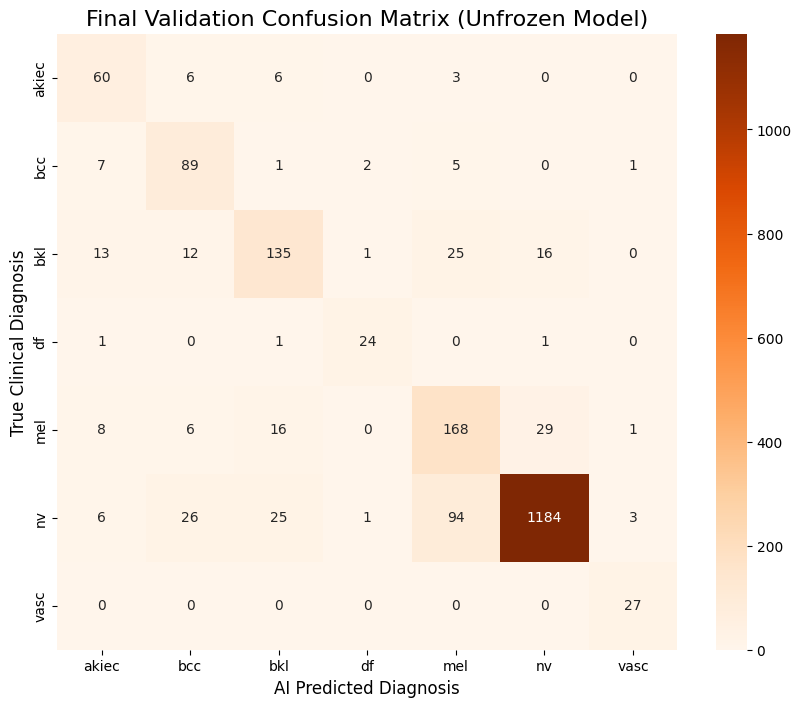

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import torch

print("Loading best unfrozen model weights for final clinical audit...")
# Load the peak performing weights saved during the 15-epoch run
if os.path.exists('best_clinical_model_unfrozen.pth'):
    model.load_state_dict(torch.load('best_clinical_model_unfrozen.pth', map_location=device))

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

target_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

# 1. Print metrics summary
print("\n" + "="*55)
print("FINAL FINE-TUNED CLASSIFICATION REPORT")
print("="*55)
print(classification_report(y_true, y_pred, target_names=target_names))

# 2. Render the heatmap matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Final Validation Confusion Matrix (Unfrozen Model)', fontsize=16)
plt.ylabel('True Clinical Diagnosis', fontsize=12)
plt.xlabel('AI Predicted Diagnosis', fontsize=12)
plt.show()

In [ ]:
from google.colab import files; files.download('best_clinical_model_unfrozen.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
#trial_testing

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image

# 1. Hardware Routing Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Inference engine running on: {device}")

# 2. Rebuild the Exact Unfrozen EfficientNet-B0 Structural Frame
def load_inference_model(weights_path='best_clinical_model_unfrozen.pth'):
    # Load standard model architecture
    model = models.efficientnet_b0(weights=None)

    # Adjust classification head back to our 7 specific classes
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, 7)

    # Load our fine-tuned weights matrix
    if os.path.exists(weights_path):
        model.load_state_dict(torch.load(weights_path, map_location=device))
        print(f"Successfully loaded optimization weights from: {weights_path}")
    else:
        raise FileNotFoundError(f"Could not find model weights at '{weights_path}'. Double check the filename.")

    model = model.to(device)
    model.eval() # Freeze Batch Normalization and Dropout layers for inference
    return model

# 3. Define the Strict Pipeline Transformation Pipeline
# This must exactly match the validation transforms we used during training
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Clinical Mapping definitions
disease_map = {
    0: ('akiec', "Actinic keratoses and Intraepithelial Carcinoma (Pre-cancerous)"),
    1: ('bcc', "Basal Cell Carcinoma (Malignant)"),
    2: ('bkl', "Benign Keratosis-like Lesions (Non-cancerous)"),
    3: ('df', "Dermatofibroma (Benign skin growth)"),
    4: ('mel', "Melanoma (Highly Malignant)"),
    5: ('nv', "Melanocytic Nevi (Common Benign Mole)"),
    6: ('vasc', "Vascular Lesions (Benign blood vessel cluster)")
}

# 4. Core Prediction Function
def predict_skin_lesion(image_path, model):
    # Open and prepare the raw image matrix
    try:
        image = Image.open(image_path).convert('RGB')
    except Exception as e:
        print(f"Error reading image file: {e}")
        return

    # Apply preprocessing adjustments and expand dimensions to create a mock batch (1, 3, 224, 224)
    input_tensor = inference_transform(image).unsqueeze(0).to(device)

    # Pass the tensor forward through the network layers without calculating gradients
    with torch.no_grad():
        logits = model(input_tensor)

        # Calculate raw probability percentages across the 7 classes
        probabilities = F.softmax(logits, dim=1)[0]

    # Extract the highest probability index
    confidence, predicted_idx = torch.max(probabilities, 0)

    short_name, full_description = disease_map[predicted_idx.item()]
    confidence_pct = confidence.item() * 100

    print("\n" + "="*60)
    print(" AI DIAGNOSTIC TRIAGE REPORT")
    print("="*60)
    print(f" Image Target:      {os.path.basename(image_path)}")
    print(f" Predicted Class:  [{short_name.upper()}] - {full_description}")
    print(f" AI Confidence:     {confidence_pct:.2f}%")
    print("="*60)

    # Print secondary possibilities if confidence is under 80%
    if confidence_pct < 80:
        print("\nClinical Note: Low-confidence prediction. Top alternatives:")
        topk_probs, topk_idxs = torch.topk(probabilities, 3)
        for i in range(1, 3):
            alt_short, _ = disease_map[topk_idxs[i].item()]
            alt_conf = topk_probs[i].item() * 100
            print(f"   -> Alternative {i}: {alt_short.upper()} ({alt_conf:.2f}%)")

# Initialize model
trained_model = load_inference_model()

Inference engine running on: cpu
Successfully loaded optimization weights from: best_clinical_model_unfrozen.pth


In [4]:
pip install pytorch-gradcam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 21.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pytorch-gradcam: filename=pytorch_gradcam-0.2.1-py3-none-any.whl size=5249 sha256=03cdac79a6c837df6c5bcd4590be8d4e4ff0f598016305c1e082718c9806b037
  Stored in directory: /root/.cache/pip/wheels/b3/37/60/ab0eb271797fc9bf2a8b6edd8e550f2ee0857031e4cc0e2509
Successfully built pytorch-gradcam


In [2]:
target_image_path = "/content/ISIC_0029319.jpg"

predict_skin_lesion(target_image_path, trained_model)


 AI DIAGNOSTIC TRIAGE REPORT
 Image Target:      ISIC_0029319.jpg
 Predicted Class:  [MEL] - Melanoma (Highly Malignant)
 AI Confidence:     80.50%


In [2]:
pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 41.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=15ad6667f8ddac988a18deedd7de29ac7a17e193535150bf597b66d8d4f2af1b
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image

# Core Grad-CAM visual tools
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# 1. Device Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Local Inference Testing Engine running on: {device}")

# 2. Rebuild the Exact 7-Class EfficientNet Frame
model = models.efficientnet_b0(weights=None)
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 7)

# 3. Pour your downloaded weights into the frame
weights_path = 'best_clinical_model_unfrozen.pth'
if os.path.exists(weights_path):
    model.load_state_dict(torch.load(weights_path, map_location=device))
    print("Model weights successfully loaded into memory.")
else:
    raise FileNotFoundError(f"Missing weight file! Place '{weights_path}' in this directory.")

model = model.to(device)
model.eval()

# 4. CRITICAL: Unfreeze the final convolutional layer for tracking map calculation
for param in model.features[-1].parameters():
    param.requires_grad = True

# Initialize the Grad-CAM targeting system
target_layers = [model.features[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

# 5. The Clinical Preprocessing Transform
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

disease_map = {
    0: ('akiec', "Actinic keratoses (Pre-cancerous)"),
    1: ('bcc', "Basal Cell Carcinoma (Malignant)"),
    2: ('bkl', "Benign Keratosis-like Lesions (Benign)"),
    3: ('df', "Dermatofibroma (Benign skin growth)"),
    4: ('mel', "Melanoma (Highly Malignant)"),
    5: ('nv', "Melanocytic Nevi (Common Benign Mole)"),
    6: ('vasc', "Vascular Lesions (Benign)")
}

# 6. Comprehensive Local Testing Function
def test_local_image_with_heatmap(image_path):
    if not os.path.exists(image_path):
        print(f"Cannot find target image at: {image_path}")
        return

    # Load and transform image
    raw_image = Image.open(image_path).convert('RGB')
    input_tensor = inference_transform(raw_image).unsqueeze(0).to(device)

    # --- STEP A: LIVE PREDICTION ---
    # NOTE: We do NOT use torch.no_grad() here because Grad-CAM requires gradient paths!
    outputs = model(input_tensor)
    probabilities = F.softmax(outputs, dim=1)[0]
    confidence, predicted_idx = torch.max(probabilities, 0)
    class_id = predicted_idx.item()

    short_name, full_description = disease_map[class_id]

    print("\n" + "="*55)
    print("LOCAL DIAGNOSTIC AUDIT REPORT")
    print("="*55)
    print(f"Image Audited:     {os.path.basename(image_path)}")
    print(f"Predicted Class:   [{short_name.upper()}] - {full_description}")
    print(f"AI Confidence:      {confidence.item() * 100:.2f}%")
    print("="*55)

    # --- STEP B: GENERATE GRAD-CAM HEATMAP ---
    targets = [ClassifierOutputTarget(class_id)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

    # Un-normalize the input tensor back to clean RGB colors for the display background
    img_np = input_tensor.squeeze(0).permute(1, 2, 0).cpu().detach().numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    rgb_background = np.clip(std * img_np + mean, 0, 1)

    # Overlay the visual heatmap over the original clean image matrix
    cam_overlay_image = show_cam_on_image(rgb_background, grayscale_cam, use_rgb=True)

    # --- STEP C: RENDER VISUAL PLOT ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Left Box: Original clean input image
    axes[0].imshow(rgb_background)
    axes[0].set_title(f"Original Target Lesion", fontsize=12)
    axes[0].axis('off')

    # Right Box: The Grad-CAM overlay heatmap showing AI attention areas
    axes[1].imshow(cam_overlay_image)
    axes[1].set_title(f"Grad-CAM Explanation [{short_name.upper()}]", fontsize=12)
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

Local Inference Testing Engine running on: cpu
Model weights successfully loaded into memory.



LOCAL DIAGNOSTIC AUDIT REPORT
Image Audited:     ISIC_0029319.jpg
Predicted Class:   [MEL] - Melanoma (Highly Malignant)
AI Confidence:      80.50%


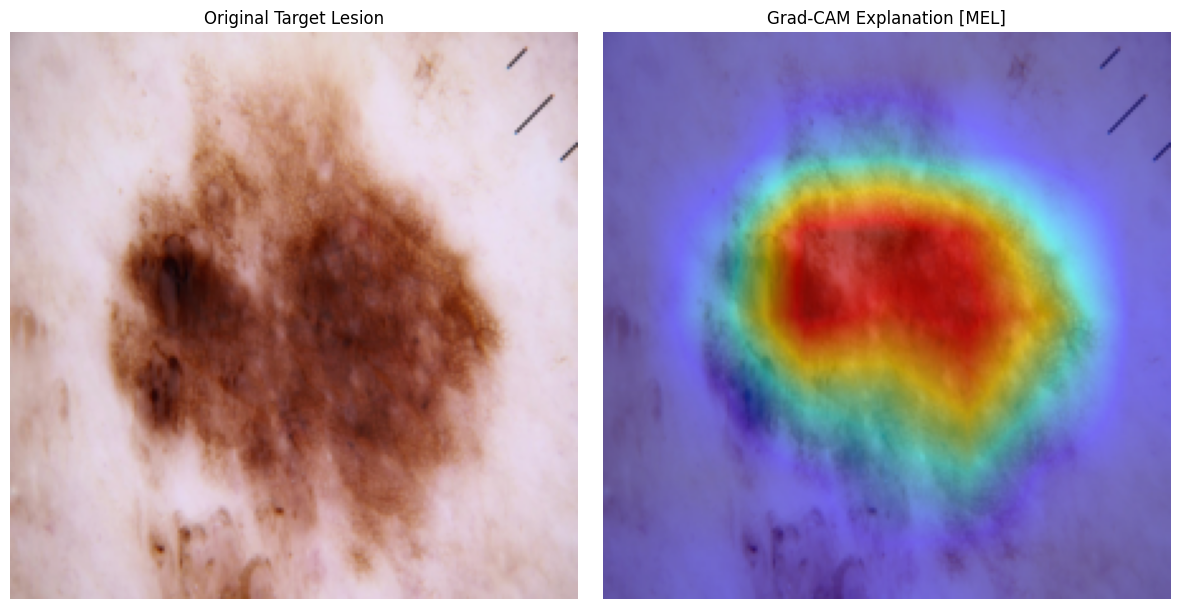

In [4]:
test_image_file = "/content/ISIC_0029319.jpg"

test_local_image_with_heatmap(test_image_file)